In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
import seaborn as sns
import sys
sys.path.append('..')

from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [2]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

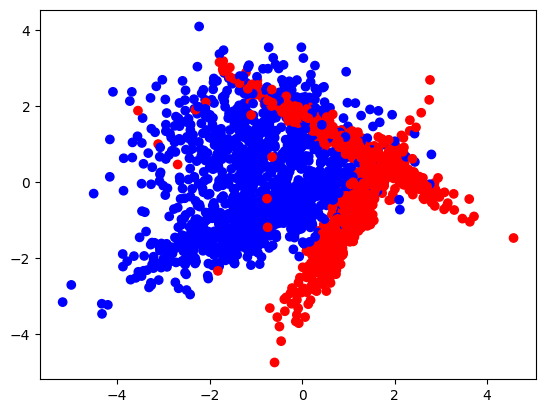

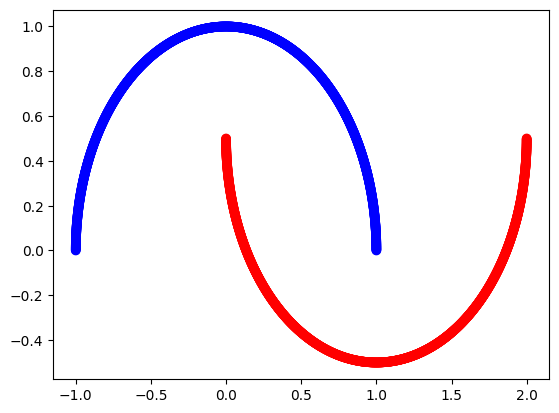

In [3]:
X_classification, y_classification = make_classification(n_samples = N_SAMPLES, n_features = 2, n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()

# Implementation

In [4]:
class RidgeLinearClassifier(ClassifierAbstraction):
    def _lambda(self, X : np.ndarray, y : np.ndarray): # plug-in lambda coefficent calculation implementation 
        n, p = X.shape
        beta = np.linalg.pinv(X) @ y
        omega = np.linalg.pinv((X.T @ X) / n)
        sigma_squared = np.linalg.norm((y - (X @ beta)))**2 / (n - p)
        
        nominator = sigma_squared * np.trace(omega)
        denominator = (beta.T @ omega @ beta) + (3 * sigma_squared * np.trace(omega@omega) / n)
        return nominator/denominator

    def fit(self, X : np.ndarray, y : np.ndarray) -> None:
        '''
        X - dataset
        y - labels from a 2 element set, ex. [0,1] or [4, 12]
        '''
        self.classes_ = np.unique(y)
        y_encoded = np.where(y == self.classes_[0], -1, 1).astype(float)

        regularization_coefficient = self._lambda(X, y_encoded)
        number_of_features = X.shape[1]
        I = np.identity(number_of_features)
        self.weights = np.linalg.inv((X.T @ X) + regularization_coefficient * I) @ X.T @ y_encoded

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights

    def predict(self, X) -> np.ndarray:
        raw_classification = self.decision_function(X)
        labels = np.sign(raw_classification)
        return np.where(labels == -1, self.classes_[0], self.classes_[1])

# Evaluation on synthetic data

### Training

In [5]:
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(X_moons, y_moons, test_size = 0.3, random_state = RANDOM_STATE, stratify=y_moons)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_classification, y_classification, test_size = 0.3, random_state = RANDOM_STATE, stratify=y_classification)

In [6]:
my_ridge_cls = RidgeLinearClassifier()
my_ridge_moons = RidgeLinearClassifier()
my_ridge_cls.fit(X_train_cls, y_train_cls)
my_ridge_moons.fit(X_train_moons, y_train_moons)

sk_ridge_cls = RidgeClassifier()
sk_ridge_moons = RidgeClassifier()
sk_ridge_cls.fit(X_train_cls, y_train_cls)
sk_ridge_moons.fit(X_train_moons, y_train_moons)

print("Finished training")

Finished training


### Testing

classification dataset

My fit time for 1000 runs: 0.0001159749993821606
Sk fit time for 1000 runs: 0.0009983940001693555

── My metrics (classification dataset):  ──
Confusion matrix:
[[310  85]
 [ 49 347]]
Accuracy:       0.8305941845764855
Sensitivity:    0.8762626262626263
Specificity:    0.7848101265822784

── Sk metrics (classification dataset):  ──
Confusion matrix:
[[310  85]
 [ 49 347]]
Accuracy:       0.8305941845764855
Sensitivity:    0.8762626262626263
Specificity:    0.7848101265822784


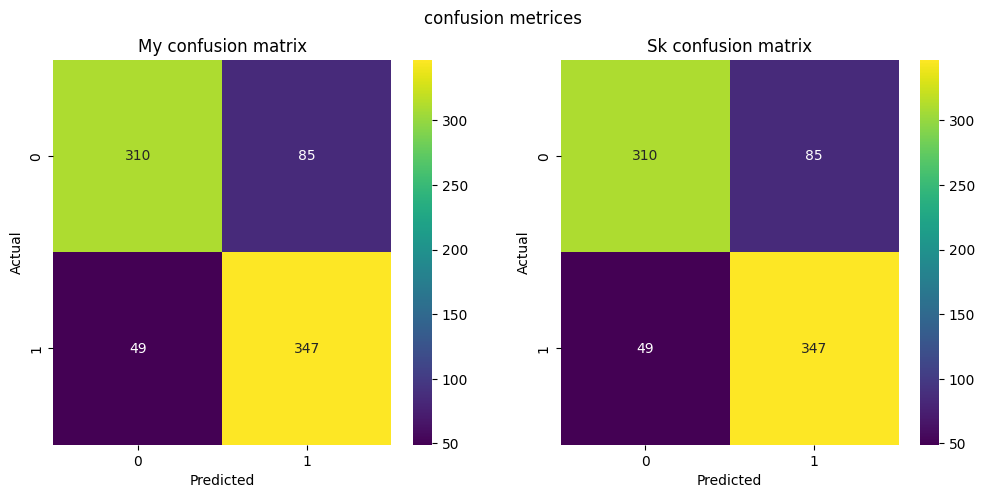

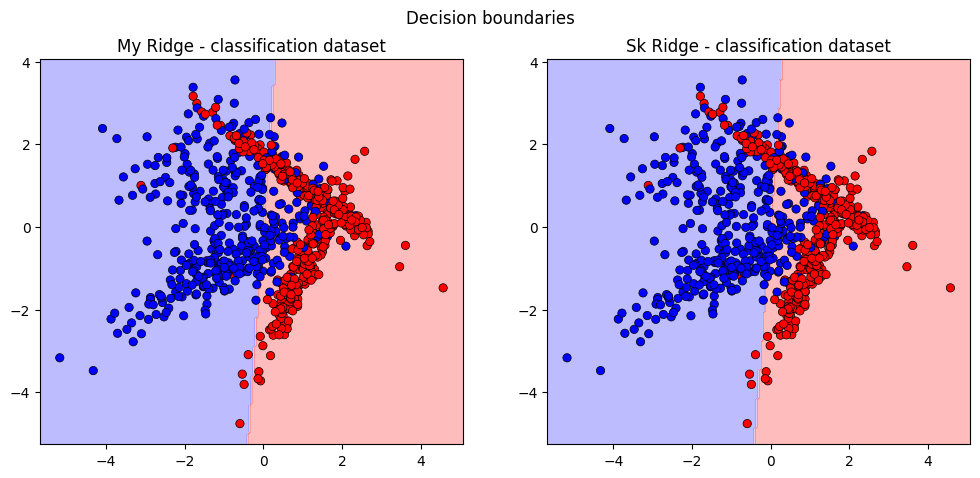

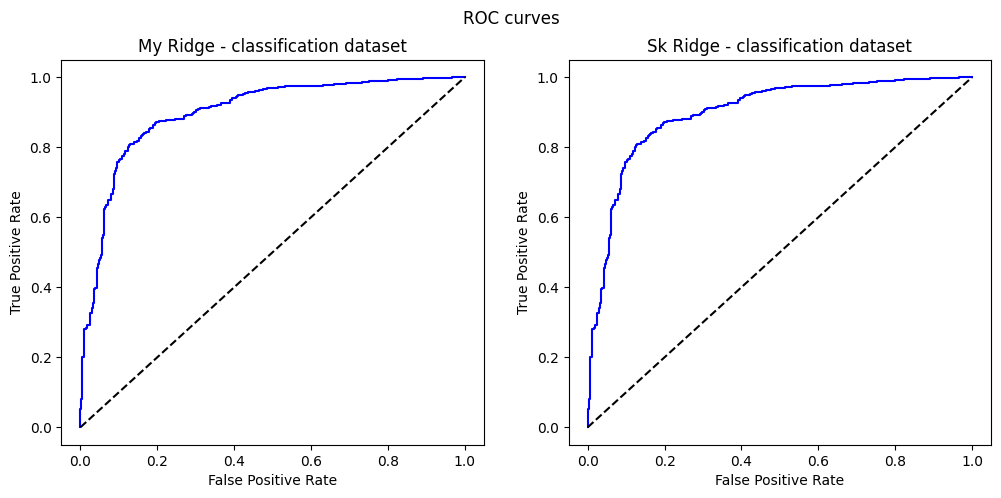

In [7]:
# Predicition on classifier dataset
n_runs = 1000
print(f"My fit time for {n_runs} runs: {measure_fit_time(my_ridge_cls, X_train = X_train_cls, y_train = y_train_cls, n_runs = n_runs)}")
print(f"Sk fit time for {n_runs} runs: {measure_fit_time(sk_ridge_cls, X_train = X_train_cls, y_train = y_train_cls, n_runs = n_runs)}")

print_metrics(my_ridge_cls, X_test_cls, y_test_cls, name="My metrics (classification dataset): ")
print_metrics(sk_ridge_cls, X_test_cls, y_test_cls, name="Sk metrics (classification dataset): ")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("confusion metrices")
plot_confusion_matrix(my_ridge_cls, X_test_cls, y_test_cls, ax=axes[0], title="My confusion matrix")
plot_confusion_matrix(sk_ridge_cls, X_test_cls, y_test_cls, ax=axes[1], title="Sk confusion matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Decision boundaries")
plot_decision_boundary(my_ridge_cls, X_test_cls, y_test_cls, ax = axes[0], title = "My Ridge - classification dataset")
plot_decision_boundary(sk_ridge_cls, X_test_cls, y_test_cls, ax = axes[1], title = "Sk Ridge - classification dataset")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC curves")
plot_roc(my_ridge_cls, X_test=X_test_cls, y_test=y_test_cls, ax = axes[0], title = "My Ridge - classification dataset")
plot_roc(sk_ridge_cls, X_test=X_test_cls, y_test=y_test_cls, ax = axes[1], title = "Sk Ridge - classification dataset")
plt.show()

moons dataset

My fit time for 1000 runs: 0.00011052230029599742
Sk fit time for 1000 runs: 0.0010126235000789165

── My metrics (moons dataset):  ──
Confusion matrix:
[[352  44]
 [ 65 330]]
Accuracy:       0.8621997471554994
Sensitivity:    0.8354430379746836
Specificity:    0.8888888888888888

── Sk metrics (moons dataset):  ──
Confusion matrix:
[[351  45]
 [ 53 342]]
Accuracy:       0.8761061946902655
Sensitivity:    0.8658227848101265
Specificity:    0.8863636363636364


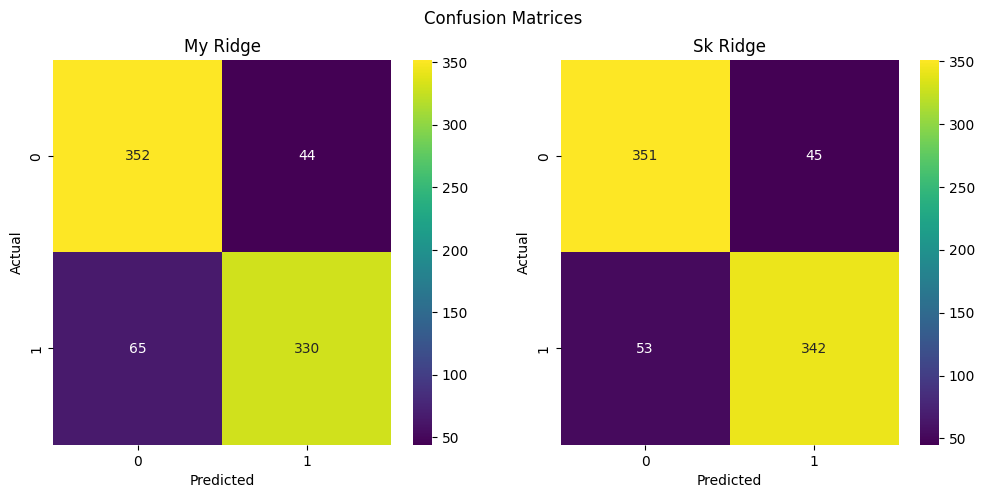

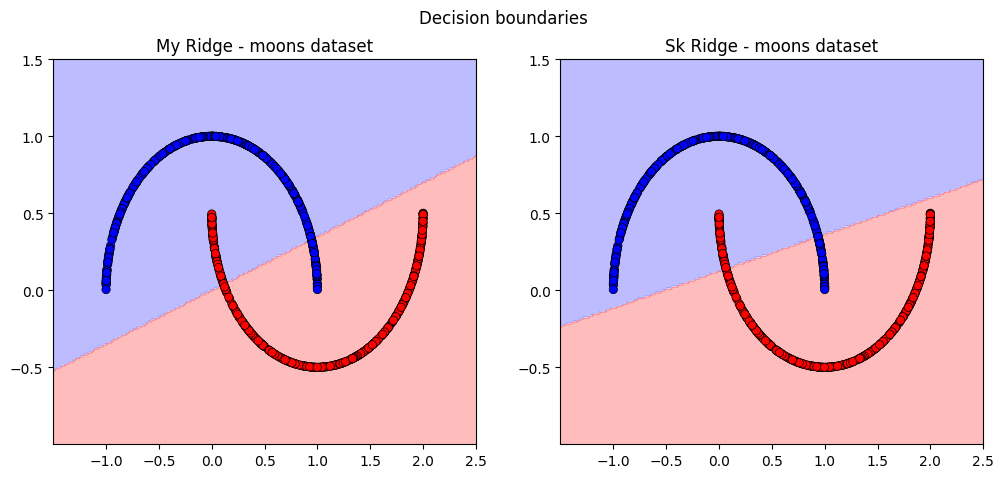

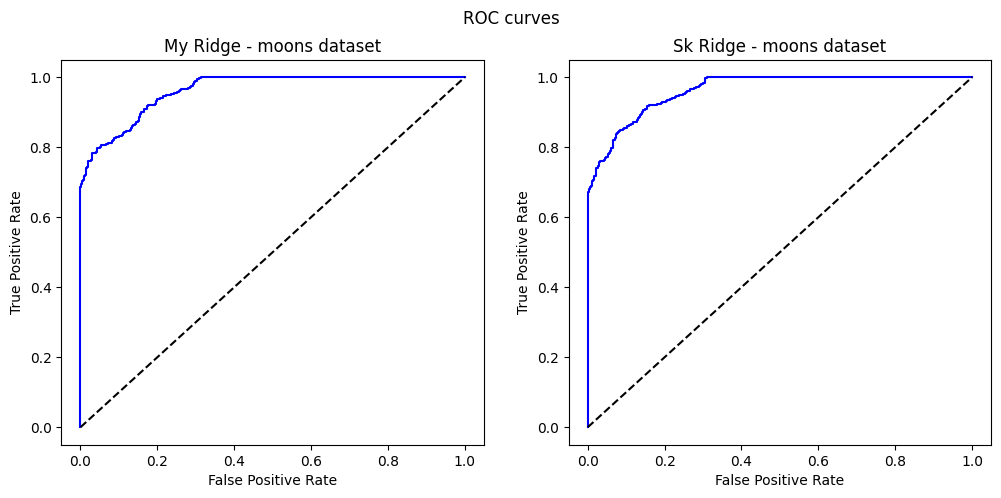

In [8]:
# Prediction on moons dataset
n_runs = 1000
print(f"My fit time for {n_runs} runs: {measure_fit_time(my_ridge_moons, X_train=X_train_moons, y_train=y_train_moons, n_runs=n_runs)}")
print(f"Sk fit time for {n_runs} runs: {measure_fit_time(sk_ridge_moons, X_train=X_train_moons, y_train=y_train_moons, n_runs=n_runs)}")

print_metrics(my_ridge_moons, X_test_moons, y_test_moons, name="My metrics (moons dataset): ")
print_metrics(sk_ridge_moons, X_test_moons, y_test_moons, name="Sk metrics (moons dataset): ")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices")
plot_confusion_matrix(my_ridge_moons, X_test_moons, y_test_moons, ax=axes[0], title="My Ridge")
plot_confusion_matrix(sk_ridge_moons, X_test_moons, y_test_moons, ax=axes[1], title="Sk Ridge")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Decision boundaries")
plot_decision_boundary(my_ridge_moons, X_test_moons, y_test_moons, ax=axes[0], title="My Ridge - moons dataset")
plot_decision_boundary(sk_ridge_moons, X_test_moons, y_test_moons, ax=axes[1], title="Sk Ridge - moons dataset")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC curves")
plot_roc(my_ridge_moons, X_test=X_test_moons, y_test=y_test_moons, ax=axes[0], title="My Ridge - moons dataset")
plot_roc(sk_ridge_moons, X_test=X_test_moons, y_test=y_test_moons, ax=axes[1], title="Sk Ridge - moons dataset")
plt.show()

____________________

# Real dataset

### Import dataset

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45)
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets

# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

### Insepcting data

In [10]:
# print(X)
# print(y)
# X

### Binarizing output y

In [11]:
print(pd.unique(y.values.ravel()))
y = (y > 0).astype(int)

[0 2 1 3 4]


# Statystical analysis

deleting missing data

In [12]:
df : pd.DataFrame = pd.concat([X, y], axis=1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [13]:
print(df.isnull().sum())
print(df[df.isnull().any(axis=1)])
df = df.dropna()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
166   52    1   3       138   223    0        0      169      0      0.0   
192   43    1   4       132   247    1        2      143      1      0.1   
266   52    1   4       128   204    1        0      156      1      1.0   
287   58    1   2       125   220    0        0      144      0      0.4   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
87       1  0.0   NaN    0  
166      1  NaN   3.0    0  
192      2  NaN   7.0    1  
266      2  0.0   NaN    1  
287      2  NaN   7.0    0  
302      1  NaN   3.0    0  


In [14]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1


proper statystical analysis

In [15]:
print(heart_disease.variables[['name', 'type']]) # Integer doesnt give any clue on wether data is Continous vs Discrete

        name         type
0        age      Integer
1        sex  Categorical
2         cp  Categorical
3   trestbps      Integer
4       chol      Integer
5        fbs  Categorical
6    restecg  Categorical
7    thalach      Integer
8      exang  Categorical
9    oldpeak      Integer
10     slope  Categorical
11        ca      Integer
12      thal  Categorical
13       num      Integer


In [16]:
# for column in df.columns:
#     print(f"__________{column}____________")
#     print(df[column].unique())

# Feature types:
feature_types = {
    'age':      'continuous',   # 41 unique values, measured in years
    'sex':      'categorical',  # binary: 0/1
    'cp':       'categorical',  # 4 types: 1,2,3,4
    'trestbps': 'continuous',   # 50 unique values, blood pressure measurement
    'chol':     'continuous',   # 150+ unique values, cholesterol measurement
    'fbs':      'categorical',  # binary: 0/1
    'restecg':  'categorical',  # 3 values: 0,1,2 (named categories)
    'thalach':  'continuous',   # 90 unique values, heart rate measurement
    'exang':    'categorical',  # binary: 0/1
    'oldpeak':  'continuous',   # decimal values like 0.1, 2.3, 6.2
    'slope':    'categorical',  # 3 values: 1,2,3 (named categories)
    'ca':       'discrete',     # counts vessels: 0,1,2,3
    'thal':     'categorical',  # 3 values: 3,6,7 (named categories)
}

Statistical parameters

In [17]:
print("_____________________________Statistical Analysis________________________________")
for feature, ftype in feature_types.items():
    col = df[feature]
    print(f"\n── {feature} ({ftype}) ──")
    if ftype == 'categorical':
        print(f"  Mode:   {col.mode()[0]}")
        print(f"  Counts: {col.value_counts().to_dict()}")
    elif ftype == 'discrete':
        print(f"  Mean:   {col.mean():.3f}")
        print(f"  Mode:   {col.mode()[0]}")
        print(f"  Std:    {col.std():.3f}")
        print(f"  Min:    {col.min():.0f}")
        print(f"  Max:    {col.max():.0f}")
        print(f"  Counts: {col.value_counts().sort_index().to_dict()}")
    elif ftype == 'continuous':
        print(f"  Mean:   {col.mean():.3f}")
        print(f"  Std:    {col.std():.3f}")
        print(f"  Min:    {col.min():.3f}")
        print(f"  Max:    {col.max():.3f}")

_____________________________Statistical Analysis________________________________

── age (continuous) ──
  Mean:   54.542
  Std:    9.050
  Min:    29.000
  Max:    77.000

── sex (categorical) ──
  Mode:   1
  Counts: {1: 201, 0: 96}

── cp (categorical) ──
  Mode:   4
  Counts: {4: 142, 3: 83, 2: 49, 1: 23}

── trestbps (continuous) ──
  Mean:   131.694
  Std:    17.763
  Min:    94.000
  Max:    200.000

── chol (continuous) ──
  Mean:   247.350
  Std:    51.998
  Min:    126.000
  Max:    564.000

── fbs (categorical) ──
  Mode:   0
  Counts: {0: 254, 1: 43}

── restecg (categorical) ──
  Mode:   0
  Counts: {0: 147, 2: 146, 1: 4}

── thalach (continuous) ──
  Mean:   149.599
  Std:    22.942
  Min:    71.000
  Max:    202.000

── exang (categorical) ──
  Mode:   0
  Counts: {0: 200, 1: 97}

── oldpeak (continuous) ──
  Mean:   1.056
  Std:    1.166
  Min:    0.000
  Max:    6.200

── slope (categorical) ──
  Mode:   1
  Counts: {1: 139, 2: 137, 3: 21}

── ca (discrete) ──
  Mean:

Histograms/barcharts

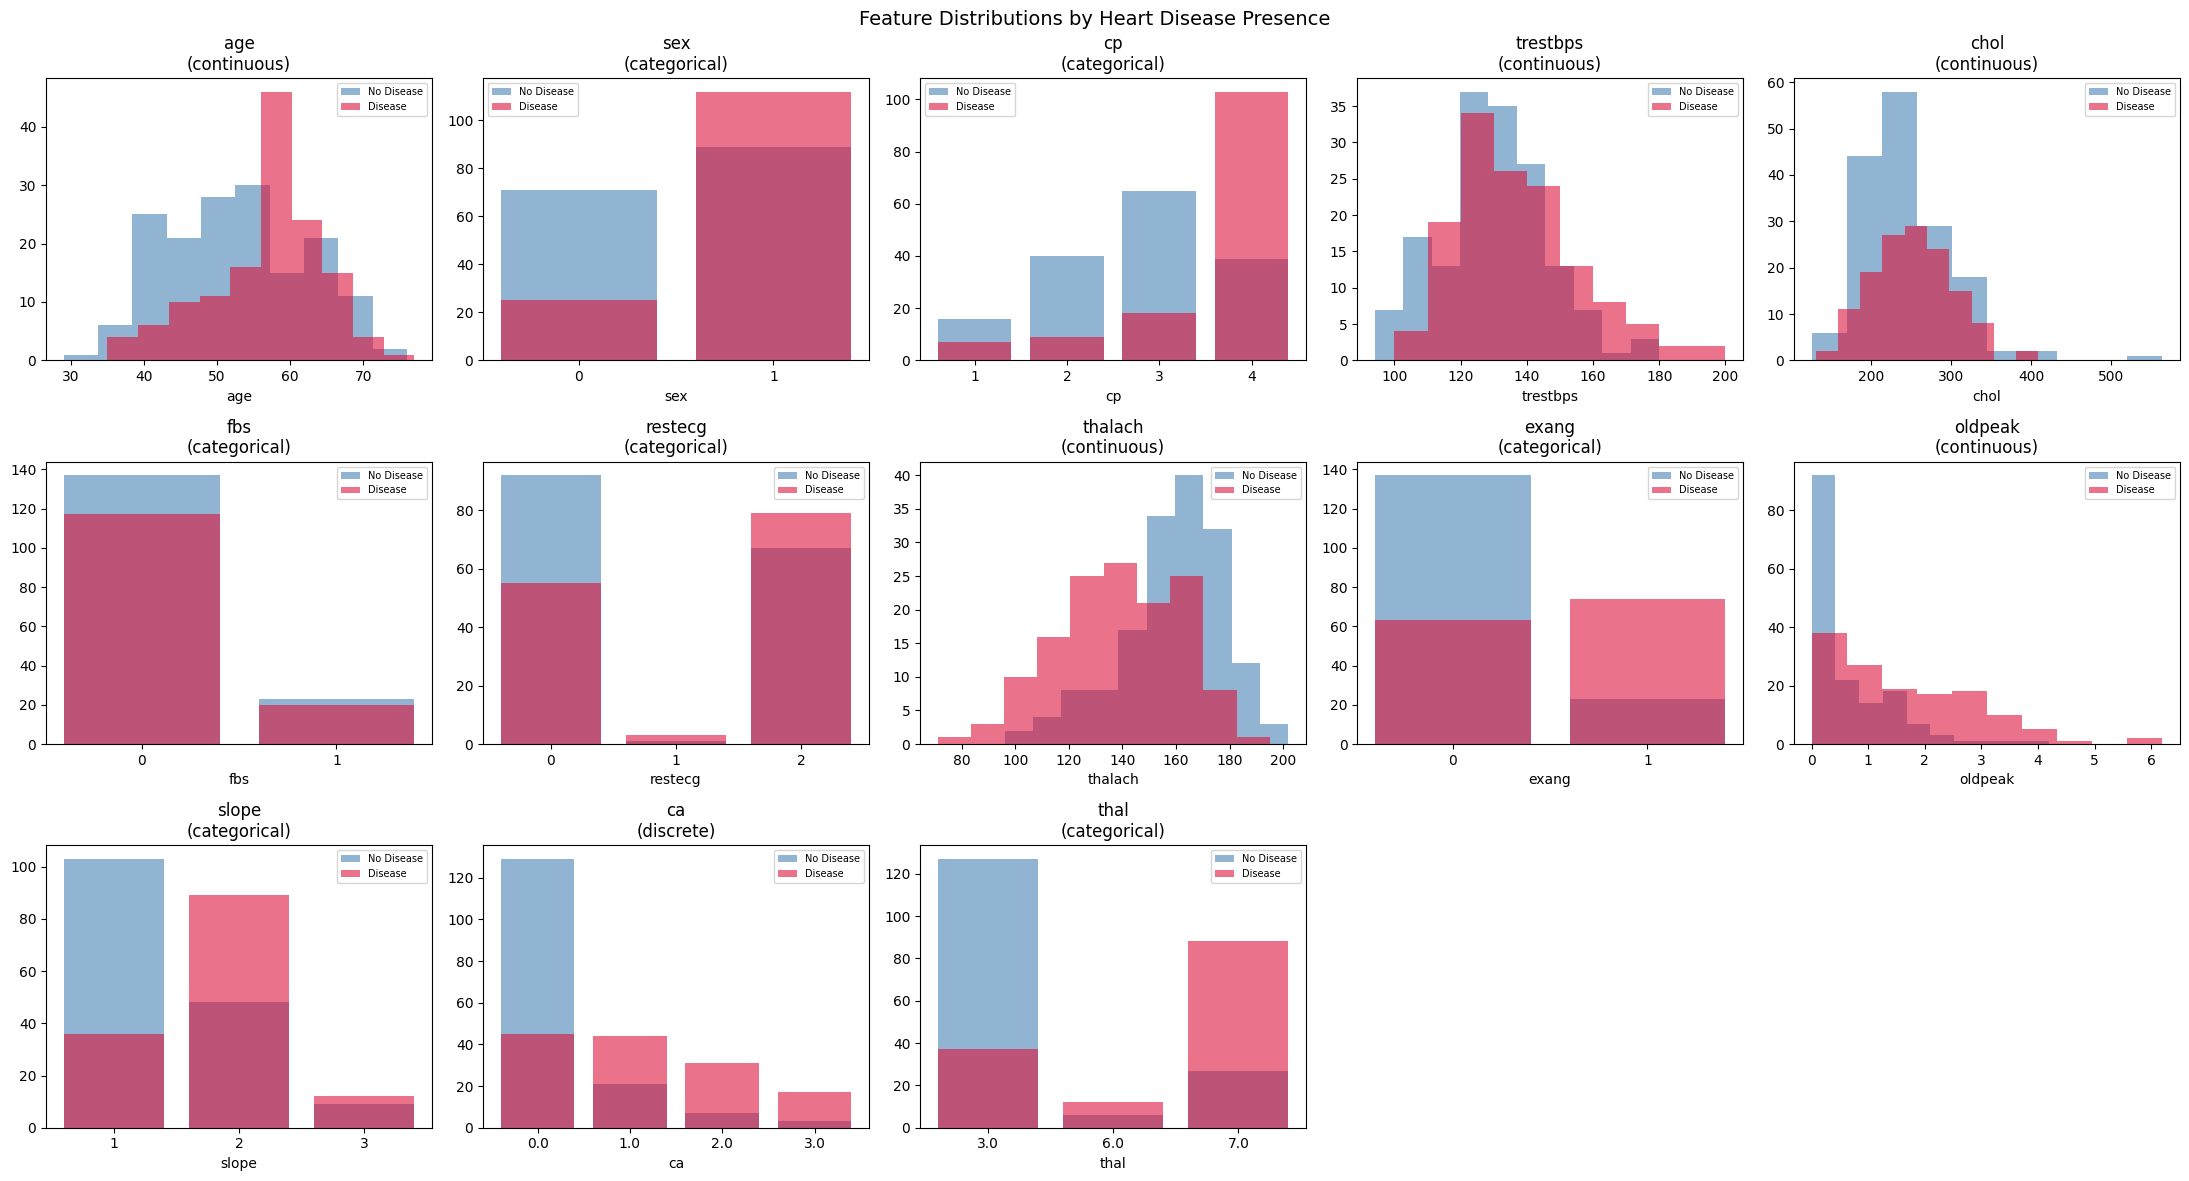

In [18]:
from matplotlib.axes import Axes

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle("Feature Distributions by Heart Disease Presence", fontsize=14)
axes = axes.flatten()

colors = {0: ('steelblue', 'No Disease'), 1: ('crimson', 'Disease')}

for i, (feature, ftype) in enumerate(feature_types.items()):
    ax : Axes = axes[i]
    for label, (color, name) in colors.items():
        mask = (df['num'] == label)
        if ftype == 'continuous':
            ax.hist(df.loc[mask, feature], alpha=0.6, color=color, label=name)
        else:  # categorical and discrete
            values : pd.Series = df.loc[mask, feature].value_counts().sort_index()
            ax.bar(values.index.astype(str), values.values, alpha=0.6, color=color, label=name)
    ax.set_title(f"{feature}\n({ftype})")
    ax.set_xlabel(feature)
    ax.legend(fontsize=7)

for j in range(len(feature_types), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Correlation

In [19]:
correlation = df.corr()
correlation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.126586,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.383652,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.268500,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.138183,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.010859,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.062209,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.018795,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.274831,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.326927,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.344976,0.424052


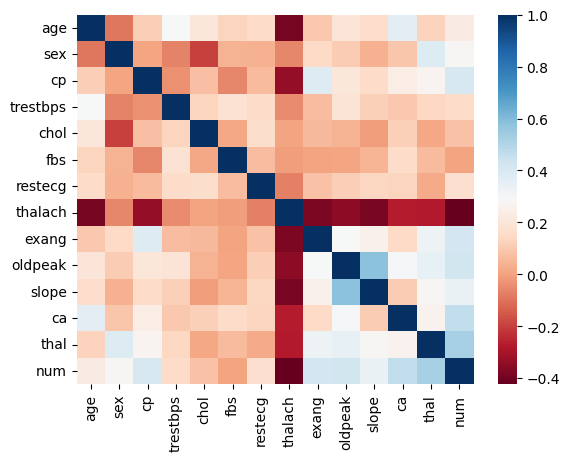

In [20]:
plt.figure()
sns.heatmap(correlation, cmap='RdBu')
plt.show()

### The best features to predict on are:  
thal - nice separation for 3 and 7;  
age - distinct peak at 60;  
cp - clear dominance of no disease for values 1,2,3 and somewhat dominant disease for 4;  
thalach - high negative correlation to many features, separated well at 160 line;  
(if 5th available then also ca)  

Those features were chosen becaue of the things stated above but also because of high correlation (or high negative) with target num [age is exception but it is one of the few not correlated to thalach]

____________________________________________________________

## Training and Evaluating on all 13 features

My fit time for 1000 runs: 0.00014707880013156683
Sk fit time for 1000 runs: 0.000951743399607949

── My metrics (all features): ──
Confusion matrix:
[[43  5]
 [ 9 33]]
Accuracy:       0.8444444444444444
Sensitivity:    0.7857142857142857
Specificity:    0.8958333333333334

── Sk metrics (all features): ──
Confusion matrix:
[[43  5]
 [ 9 33]]
Accuracy:       0.8444444444444444
Sensitivity:    0.7857142857142857
Specificity:    0.8958333333333334


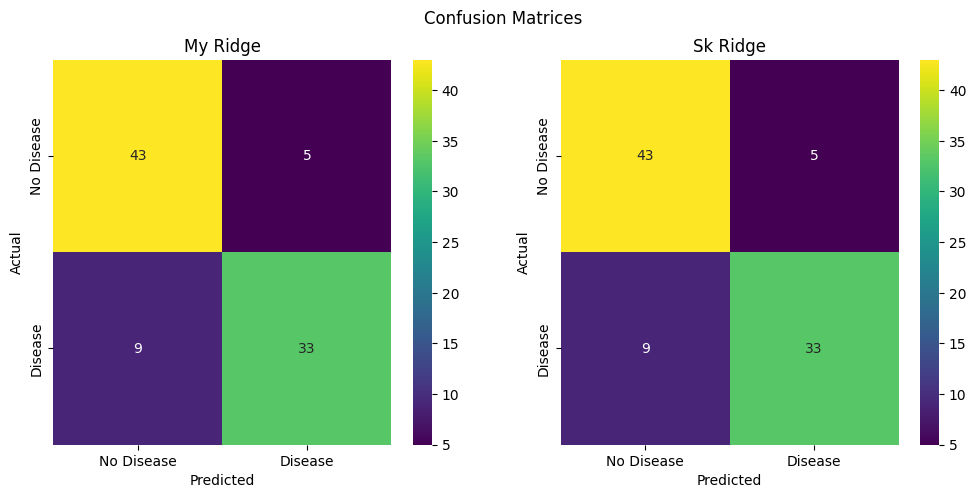

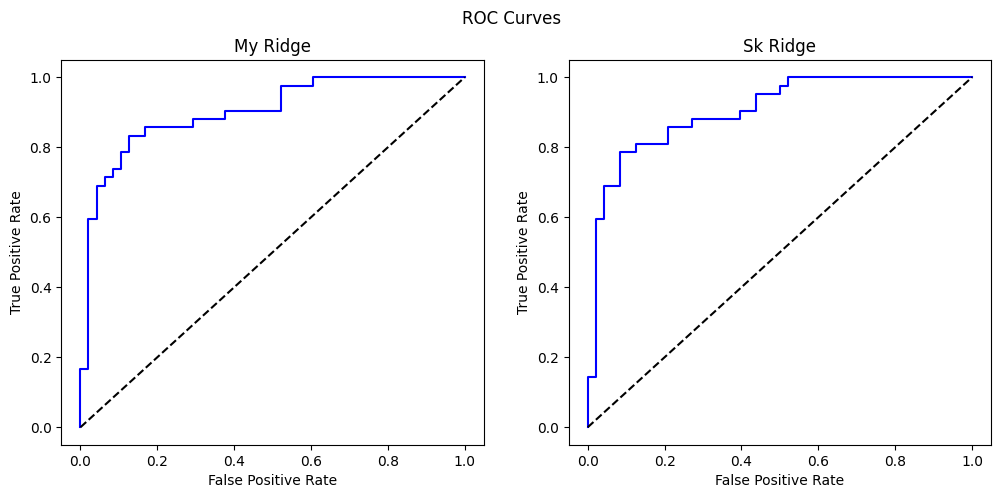

In [21]:
X_all = df.drop(columns='num').values
y_all = df['num'].values
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(X_all, y_all, test_size=0.3, random_state=RANDOM_STATE, stratify=y_all)

my_ridge_all = RidgeLinearClassifier()
sk_ridge_all = RidgeClassifier()
my_ridge_all.fit(X_all_train, y_all_train)
sk_ridge_all.fit(X_all_train, y_all_train)

n_runs = 1000
print(f"My fit time for {n_runs} runs: {measure_fit_time(my_ridge_all, X_train=X_all_train, y_train=y_all_train, n_runs=n_runs)}")
print(f"Sk fit time for {n_runs} runs: {measure_fit_time(sk_ridge_all, X_train=X_all_train, y_train=y_all_train, n_runs=n_runs)}")

print_metrics(my_ridge_all, X_all_test, y_all_test, name="My metrics (all features):")
print_metrics(sk_ridge_all, X_all_test, y_all_test, name="Sk metrics (all features):")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices")
plot_confusion_matrix(my_ridge_all, X_all_test, y_all_test, ax=axes[0], labels=['No Disease', 'Disease'], title="My Ridge")
plot_confusion_matrix(sk_ridge_all, X_all_test, y_all_test, ax=axes[1], labels=['No Disease', 'Disease'], title="Sk Ridge")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves")
plot_roc(my_ridge_all, X_all_test, y_all_test, ax=axes[0], title="My Ridge")
plot_roc(sk_ridge_all, X_all_test, y_all_test, ax=axes[1], title="Sk Ridge")
plt.show()

## Training and Evaluating on manually chosen 4 features

My fit time for 1000 runs: 7.781249965773895e-05
Sk fit time for 1000 runs: 0.0008064465001807548

── My metrics (manual features): ──
Confusion matrix:
[[41  7]
 [10 32]]
Accuracy:       0.8111111111111111
Sensitivity:    0.7619047619047619
Specificity:    0.8541666666666666

── Sk metrics (manual features): ──
Confusion matrix:
[[41  7]
 [11 31]]
Accuracy:       0.8
Sensitivity:    0.7380952380952381
Specificity:    0.8541666666666666


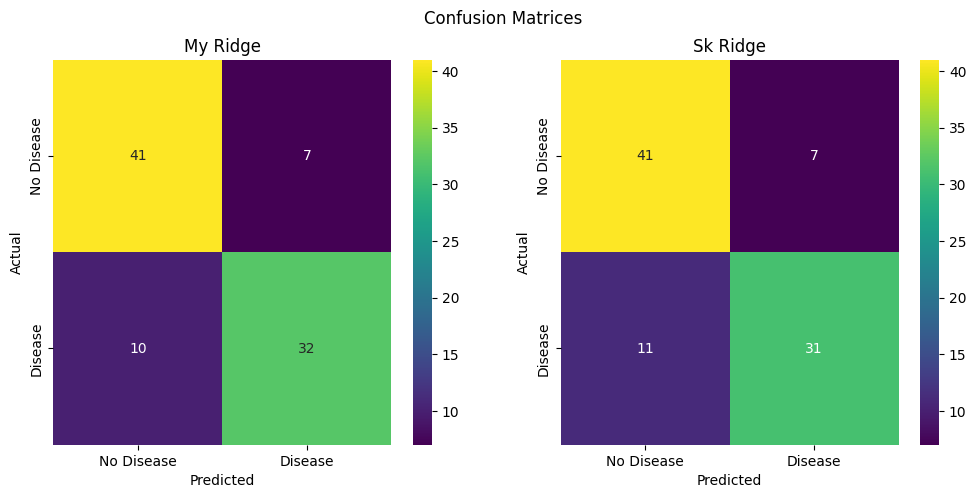

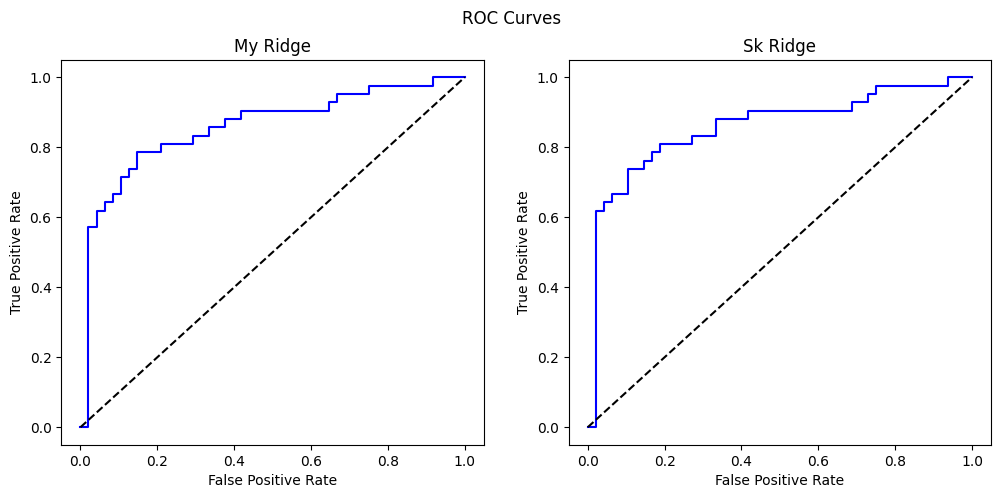

In [25]:
manual_features = ['age', 'cp', 'thal', 'thalach']
# manual_features = ['ca', 'cp', 'thal', 'thalach'] # AFTER TESTING TURNS OUT CA WAS BETTER CHOIC THAN AGE

X_manual = df[manual_features].values
y_manual = df['num'].values
X_manual_train, X_manual_test, y_manual_train, y_manual_test = train_test_split(X_manual, y_manual, test_size=0.3, random_state=RANDOM_STATE, stratify=y_manual)

my_ridge_manual = RidgeLinearClassifier()
sk_ridge_manual = RidgeClassifier()
my_ridge_manual.fit(X_manual_train, y_manual_train)
sk_ridge_manual.fit(X_manual_train, y_manual_train)

n_runs = 1000
print(f"My fit time for {n_runs} runs: {measure_fit_time(my_ridge_manual, X_train=X_manual_train, y_train=y_manual_train, n_runs=n_runs)}")
print(f"Sk fit time for {n_runs} runs: {measure_fit_time(sk_ridge_manual, X_train=X_manual_train, y_train=y_manual_train, n_runs=n_runs)}")

print_metrics(my_ridge_manual, X_manual_test, y_manual_test, name="My metrics (manual features):")
print_metrics(sk_ridge_manual, X_manual_test, y_manual_test, name="Sk metrics (manual features):")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices")
plot_confusion_matrix(my_ridge_manual, X_manual_test, y_manual_test, ax=axes[0], labels=['No Disease', 'Disease'], title="My Ridge")
plot_confusion_matrix(sk_ridge_manual, X_manual_test, y_manual_test, ax=axes[1], labels=['No Disease', 'Disease'], title="Sk Ridge")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves")
plot_roc(my_ridge_manual, X_manual_test, y_manual_test, ax=axes[0], title="My Ridge")
plot_roc(sk_ridge_manual, X_manual_test, y_manual_test, ax=axes[1], title="Sk Ridge")
plt.show()

## Training and Evaluating on automatically chosen 4 features

Auto selected features: ['exang', 'slope', 'ca', 'thal']
Manual features:        ['age', 'cp', 'thal', 'thalach']
Overlap:                {'thal'}
My fit time: 7.190099981380626e-05
Sk fit time: 0.000826858100364916

── My metrics (auto features): ──
Confusion matrix:
[[34 14]
 [ 8 34]]
Accuracy:       0.7555555555555555
Sensitivity:    0.8095238095238095
Specificity:    0.7083333333333334

── Sk metrics (auto features): ──
Confusion matrix:
[[40  8]
 [ 9 33]]
Accuracy:       0.8111111111111111
Sensitivity:    0.7857142857142857
Specificity:    0.8333333333333334


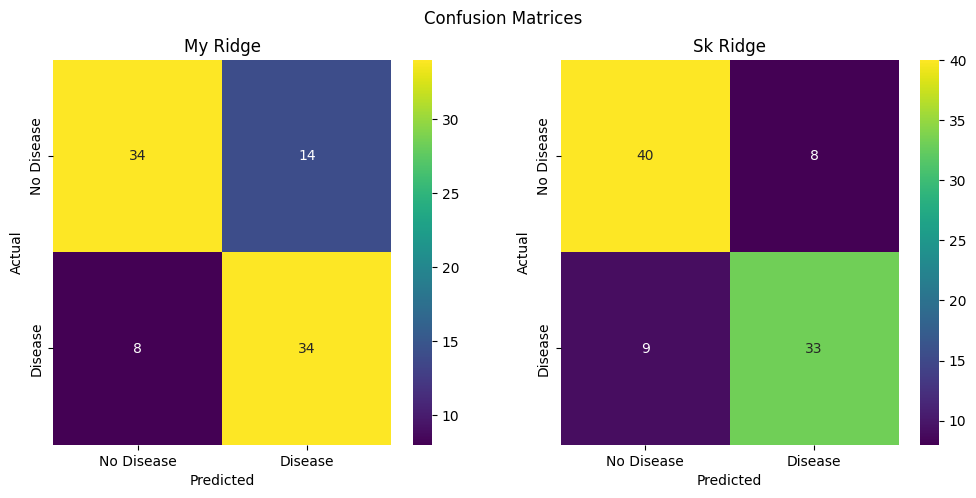

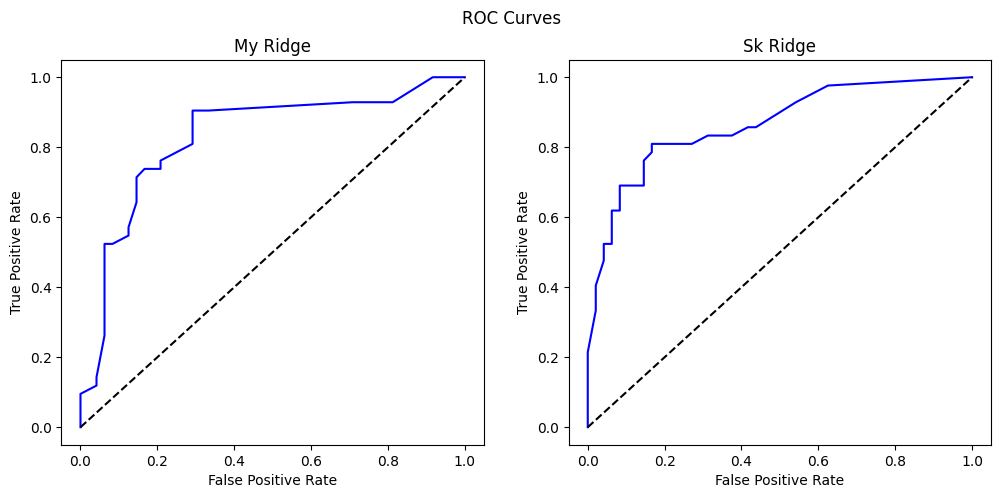

In [23]:
from sklearn.feature_selection import SequentialFeatureSelector

X_auto = df.drop(columns='num').values
y_auto = df['num'].values
X_auto_train, X_auto_test, y_auto_train, y_auto_test = train_test_split(X_auto, y_auto, test_size=0.3, random_state=RANDOM_STATE, stratify=y_auto)

sfs = SequentialFeatureSelector(RidgeClassifier(), n_features_to_select=4, direction='forward')
sfs.fit(X_auto_train, y_auto_train)

feature_names = df.drop(columns='num').columns
auto_features = feature_names[sfs.get_support()].to_list()
print(f"Auto selected features: {auto_features}")
print(f"Manual features:        {manual_features}")
print(f"Overlap:                {set(manual_features) & set(auto_features)}")

X_auto_train = sfs.transform(X_auto_train)
X_auto_test  = sfs.transform(X_auto_test)

my_ridge_auto = RidgeLinearClassifier()
sk_ridge_auto = RidgeClassifier()
my_ridge_auto.fit(X_auto_train, y_auto_train)
sk_ridge_auto.fit(X_auto_train, y_auto_train)

n_runs = 1000
print(f"My fit time: {measure_fit_time(my_ridge_auto, X_train=X_auto_train, y_train=y_auto_train, n_runs=n_runs)}")
print(f"Sk fit time: {measure_fit_time(sk_ridge_auto, X_train=X_auto_train, y_train=y_auto_train, n_runs=n_runs)}")

print_metrics(my_ridge_auto, X_auto_test, y_auto_test, name="My metrics (auto features):")
print_metrics(sk_ridge_auto, X_auto_test, y_auto_test, name="Sk metrics (auto features):")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices")
plot_confusion_matrix(my_ridge_auto, X_auto_test, y_auto_test, ax=axes[0], labels=['No Disease', 'Disease'], title="My Ridge")
plot_confusion_matrix(sk_ridge_auto, X_auto_test, y_auto_test, ax=axes[1], labels=['No Disease', 'Disease'], title="Sk Ridge")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves")
plot_roc(my_ridge_auto, X_auto_test, y_auto_test, ax=axes[0], title="My Ridge")
plot_roc(sk_ridge_auto, X_auto_test, y_auto_test, ax=axes[1], title="Sk Ridge")
plt.show()